In [21]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import mglearn
from sklearn.model_selection import train_test_split

- 主成分分析

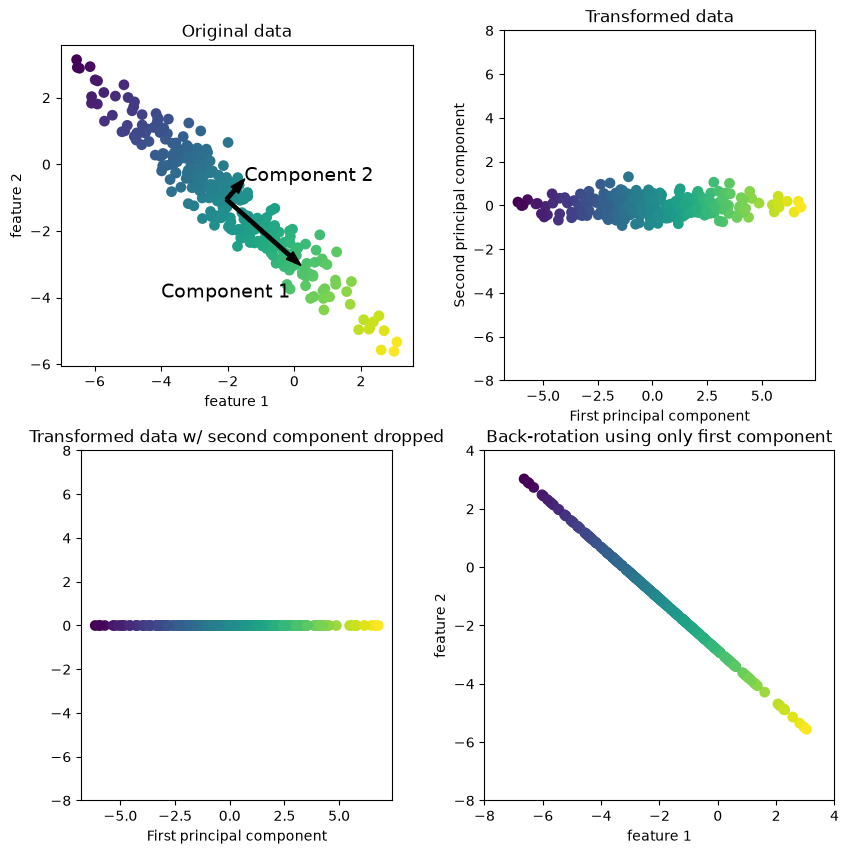

In [22]:
mglearn.plots.plot_pca_illustration()

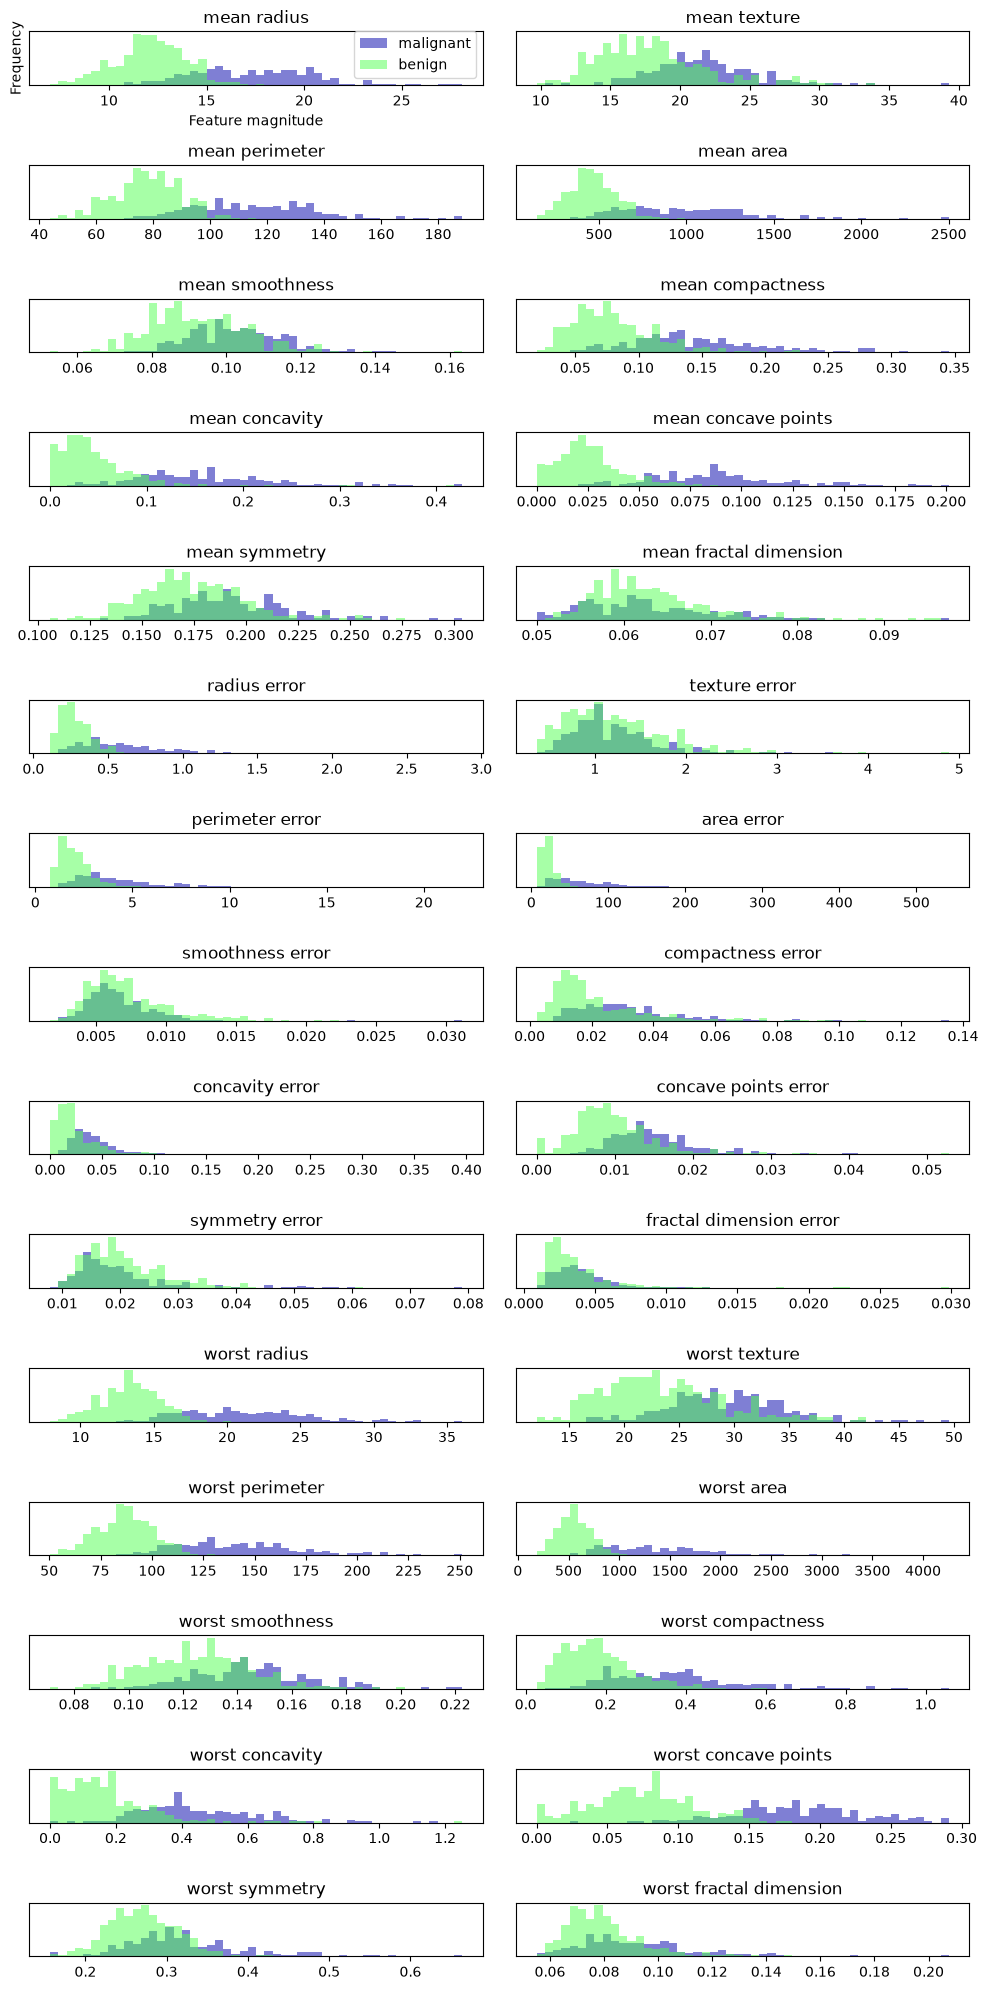

In [23]:
#特徴量ごとに２つのクラス（良性と悪性）のヒストグラムを可視化

from sklearn.datasets import load_breast_cancer
import numpy as np
cancer = load_breast_cancer()

fig, axes = plt.subplots(15, 2, figsize=(10, 20))
malignant = cancer.data[cancer.target == 0]
benign = cancer.data[cancer.target == 1]

ax = axes.ravel()

for i in range(30):
    _, bins = np.histogram(cancer.data[:, i], bins=50)
    ax[i].hist(malignant[:, i], bins=bins, color=mglearn.cm3(0), alpha=.5)
    ax[i].hist(benign[:, i], bins=bins, color=mglearn.cm3(2), alpha=.5)
    ax[i].set_title(cancer.feature_names[i])
    ax[i].set_yticks(())
ax[0].set_xlabel("Feature magnitude")
ax[0].set_ylabel("Frequency")
ax[0].legend(["malignant", "benign"], loc="best")
fig.tight_layout()

plt.show()


In [24]:
#PCAを使って、乳がんデータセットの特徴量を2次元に削減して可視化する

#PCAを用いる前に、データを標準化する
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaler.fit(cancer.data)
x_scaled = scaler.transform(cancer.data)

from sklearn.decomposition import PCA
pca = PCA(n_components=2)   #データの最初の2つの主成分を抽出する
pca.fit(x_scaled)

#最初の二つの主成分に対してデータポイントを変換
x_pca = pca.transform(x_scaled)

print("Original shape: {}".format(str(x_scaled.shape)))
print("Reduced shape: {}".format(str(x_pca.shape)))

Original shape: (569, 30)
Reduced shape: (569, 2)


Text(0, 0.5, 'Second principal component')

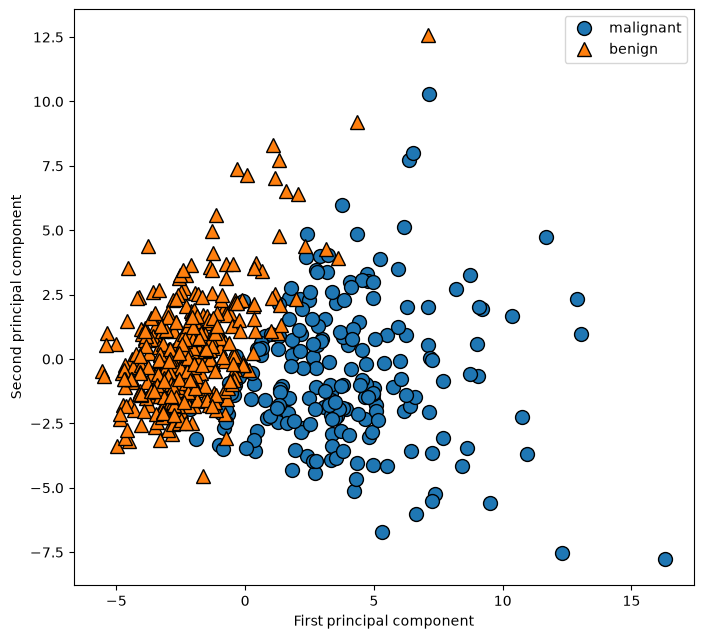

In [25]:
plt.figure(figsize=(8,8))
mglearn.discrete_scatter(x_pca[:, 0], x_pca[:, 1], cancer.target)
plt.legend(cancer.target_names, loc="best")
plt.gca().set_aspect("equal")       #今のグラフの縦横比を、xの1とyの1が同じ長さになるように設定
plt.xlabel("First principal component")
plt.ylabel("Second principal component")

In [26]:
print("PCA component shape:{}".format(pca.components_.shape))

PCA component shape:(2, 30)


In [27]:
#components_の中身を見る
#components_は、各主成分の方向を表すベクトルを格納している
print("PCA components:\n{}".format(pca.components_))

PCA components:
[[ 0.21890244  0.10372458  0.22753729  0.22099499  0.14258969  0.23928535
   0.25840048  0.26085376  0.13816696  0.06436335  0.20597878  0.01742803
   0.21132592  0.20286964  0.01453145  0.17039345  0.15358979  0.1834174
   0.04249842  0.10256832  0.22799663  0.10446933  0.23663968  0.22487053
   0.12795256  0.21009588  0.22876753  0.25088597  0.12290456  0.13178394]
 [-0.23385713 -0.05970609 -0.21518136 -0.23107671  0.18611302  0.15189161
   0.06016536 -0.0347675   0.19034877  0.36657547 -0.10555215  0.08997968
  -0.08945723 -0.15229263  0.20443045  0.2327159   0.19720728  0.13032156
   0.183848    0.28009203 -0.21986638 -0.0454673  -0.19987843 -0.21935186
   0.17230435  0.14359317  0.09796411 -0.00825724  0.14188335  0.27533947]]


Text(0, 0.5, 'Principal Components')

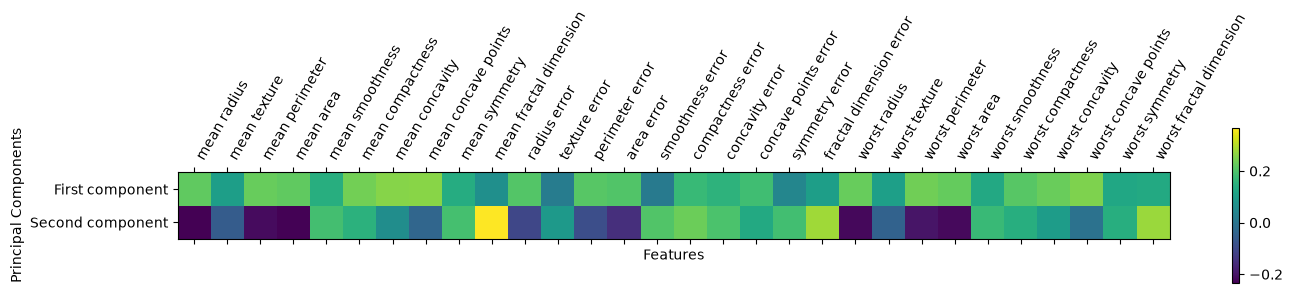

In [28]:
#係数をヒートマップにしてみてみる
plt.matshow(pca.components_,cmap="viridis")
plt.yticks([0, 1], ["First component", "Second component"])
plt.colorbar()
plt.xlabel("Features")
plt.ylabel("Principal Components")
plt.xticks(range(len(cancer.feature_names)), cancer.feature_names, rotation=60, ha="left")
plt.xlabel("Features")
plt.ylabel("Principal Components")

- 固有顔による特徴量抽出

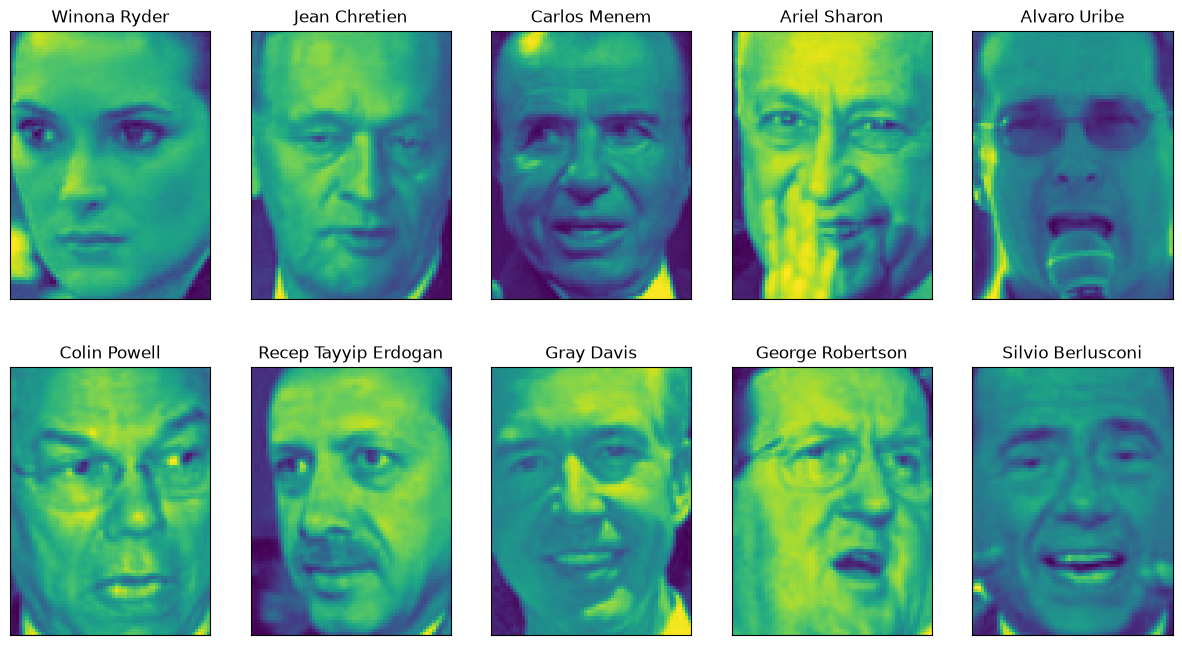

In [29]:
from sklearn.datasets import fetch_lfw_people
people = fetch_lfw_people(min_faces_per_person=20, resize=0.7)
image_shape = people.images[0].shape

fig, axes = plt.subplots(2, 5, figsize=(15, 8), subplot_kw={'xticks': (), 'yticks': ()})
for target, image, ax in zip(people.target, people.images, axes.ravel()):
    ax.imshow(image)
    ax.set_title(people.target_names[target])
    
plt.show()

In [30]:
print("people.images shape:{}".format(people.images.shape))
print("Number of classes:{}".format(len(np.unique(people.target_names))))

people.images shape:(3023, 87, 65)
Number of classes:62


In [31]:
#各ターゲットの出現回数をカウント
#bincountは、非負整数の配列を受け取り、各整数の出現回数をカウントする
counts = np.bincount(people.target)

#各ターゲットの出現回数を並べて表示
for i,(count,name) in enumerate(zip(counts,people.target_names)):
    print("{0:25}{1:3}".format(name,count),end="   ")
    if (i+1) % 3 == 0:
        print()

Alejandro Toledo          39   Alvaro Uribe              35   Amelie Mauresmo           21   
Andre Agassi              36   Angelina Jolie            20   Ariel Sharon              77   
Arnold Schwarzenegger     42   Atal Bihari Vajpayee      24   Bill Clinton              29   
Carlos Menem              21   Colin Powell             236   David Beckham             31   
Donald Rumsfeld          121   George Robertson          22   George W Bush            530   
Gerhard Schroeder        109   Gloria Macapagal Arroyo   44   Gray Davis                26   
Guillermo Coria           30   Hamid Karzai              22   Hans Blix                 39   
Hugo Chavez               71   Igor Ivanov               20   Jack Straw                28   
Jacques Chirac            52   Jean Chretien             55   Jennifer Aniston          21   
Jennifer Capriati         42   Jennifer Lopez            21   Jeremy Greenstock         24   
Jiang Zemin               20   John Ashcroft             53 

In [41]:
#偏りを減らすため、各人の画像を50枚までに制限する

#people.target と同じ個数だけ False を用意する
mask = np.zeros(people.target.shape,dtype=bool)

for target in np.unique(people.target):
    #np.where(people.target == target)[0]で、targetに一致するインデックスの配列を取得し、[:50]で最初の50個を取り出す。
    mask[np.where(people.target == target)[0][:50]] = True  

#maskがTrueのものだけを抽出する
x_people = people.data[mask]
y_people = people.target[mask]

In [42]:
#簡単な方法として1-最近傍法クラス分類器を使ってみるが、5655個の生ピクセルで距離を測るのは厳しい
from sklearn.neighbors import KNeighborsClassifier
x_train, x_test, y_train, y_test = train_test_split(
    x_people,
    y_people,
    stratify=y_people,
    random_state=0
)

knn = KNeighborsClassifier(n_neighbors=1)
knn.fit(x_train, y_train)
    
print("Test set score of 1-nn:{:.2f}".format(knn.score(x_test, y_test)))

Test set score of 1-nn:0.22


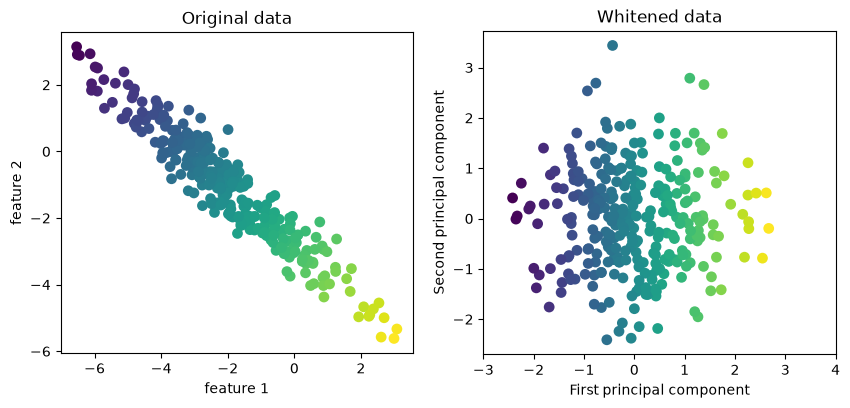

In [34]:
#whiteningを使って、PCAの結果を正規化することで、特徴量間の相関を減らすことができる
#PCAでは本来、「分散が大きい主成分ほど多くの情報を持っている」と考える。
#whiteningはその大小を消してしまうので、場合によってはノイズまで強調してしまうことに注意
mglearn.plots.plot_pca_whitening()

In [35]:
#PCAオブジェクトを訓練し、最初の100個の主成分を抽出する
pca = PCA(n_components=100,whiten=True,random_state=0).fit(x_train)
x_train_pca = pca.transform(x_train)
x_test_pca = pca.transform(x_test)

print("x_train_pca shape:{}".format(x_train_pca.shape))

x_train_pca shape:(1547, 100)


In [36]:
#これを使って、1-最近傍法クラス分類器を訓練してみる
knn = KNeighborsClassifier(n_neighbors=1)
knn.fit(x_train_pca, y_train)

#精度が向上したため、PCAで次元削減した方が良いことがわかる
print("Test set accuracy of 1-nn on PCA-reduced data:{:.2f}".format(knn.score(x_test_pca, y_test)))

Test set accuracy of 1-nn on PCA-reduced data:0.30


In [37]:
#画像データについては、見つけた主成分を容易に可視化することができる

print("PCA components shepe:{}".format(pca.components_.shape))

PCA components shepe:(100, 5655)


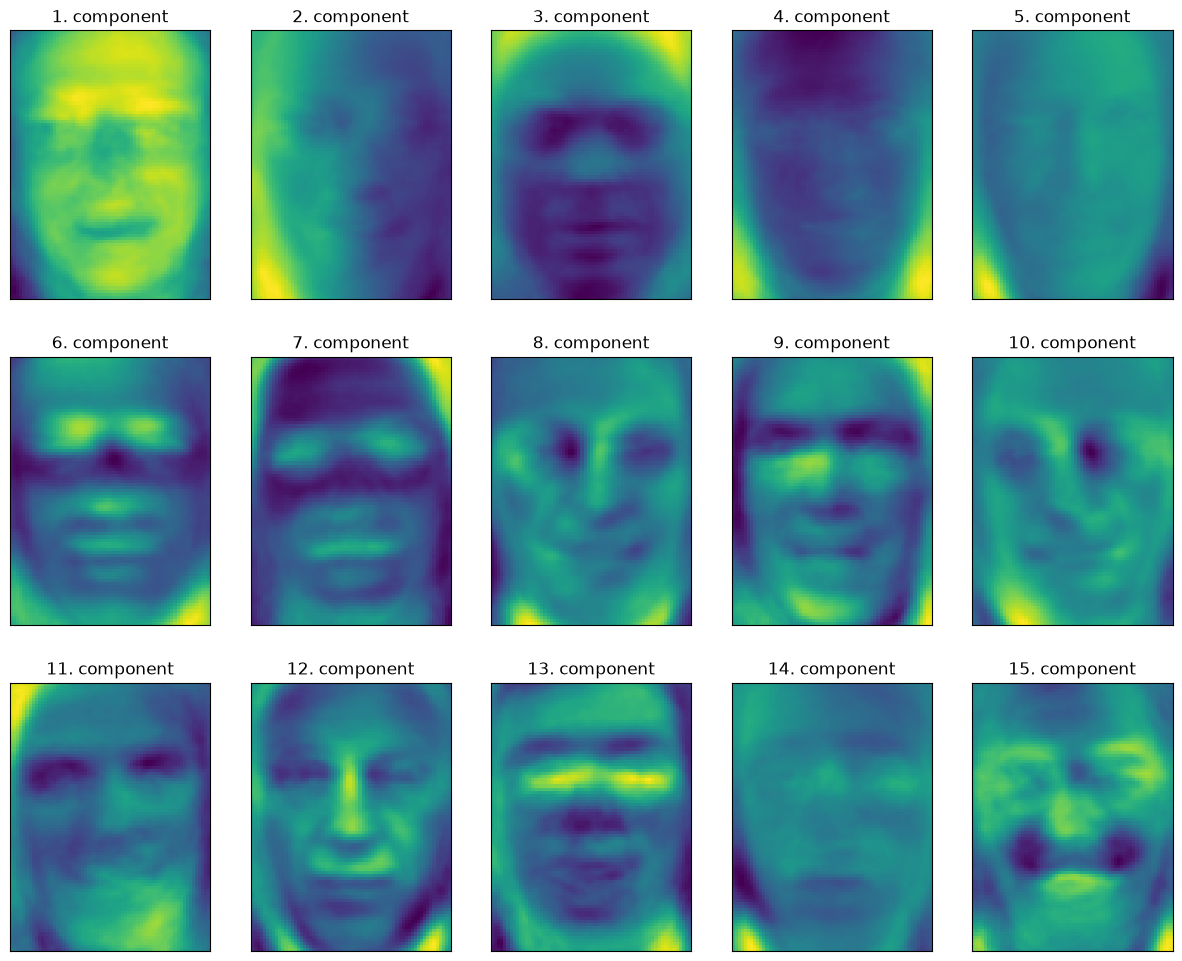

In [38]:
fig,axes = plt.subplots(3,5,figsize=(15,12),subplot_kw={'xticks':(), 'yticks':()})
for i,(components,ax) in enumerate(zip(pca.components_,axes.ravel())):
    ax.imshow(components.reshape(image_shape),cmap="viridis")
    ax.title.set_text("{}. component".format(i+1))

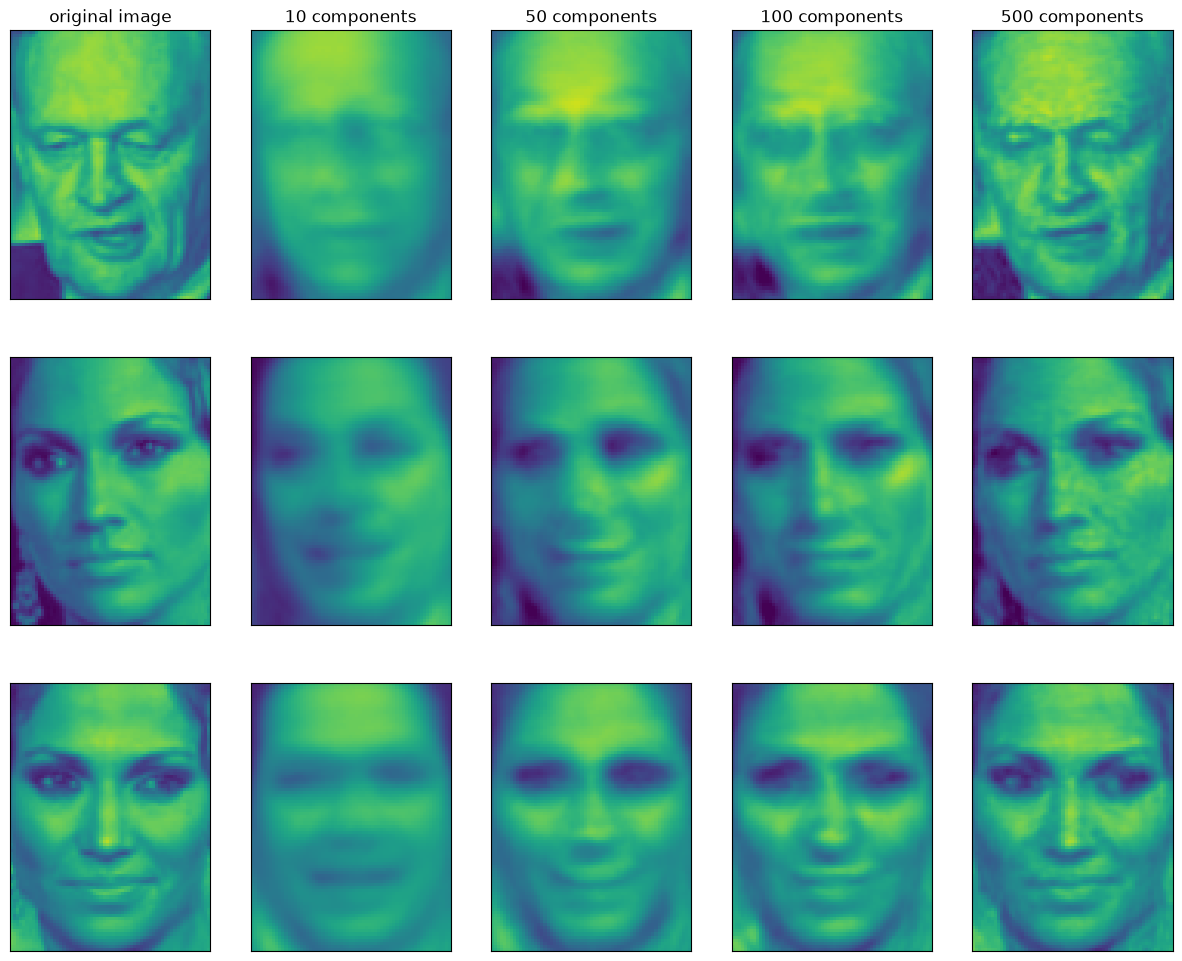

In [ ]:
#pcaの結果を使って、顔画像を再構成することもできる(pca.inverse_transform(...))
mglearn.plots.plot_pca_faces(x_train,x_test,image_shape)

Text(0, 0.5, 'Second principal component')

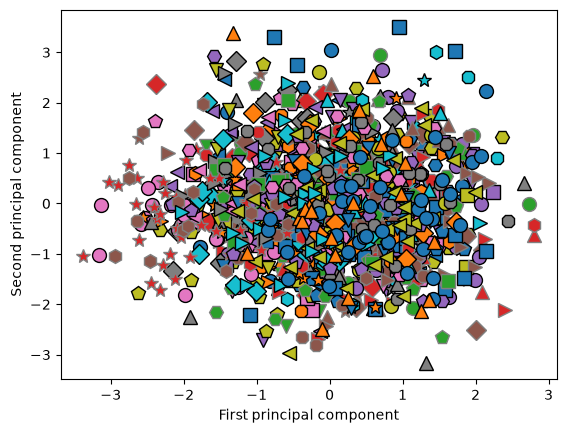

In [44]:
#PCAデータを用いてデータセット中の全ての顔を最初の二つの主成分を用いて散布図にプロットしてみる
mglearn.discrete_scatter(x_train_pca[:, 0], x_train_pca[:, 1], y_train)
plt.xlabel("First principal component")
plt.ylabel("Second principal component")

- 非負値行列因子分解(NMF)

c:\Users\seita\anaconda3\envs\ml\Lib\site-packages\sklearn\decomposition\_nmf.py:1723: ConvergenceWarning: Maximum number of iterations 200 reached. Increase it to improve convergence.
  warnings.warn(


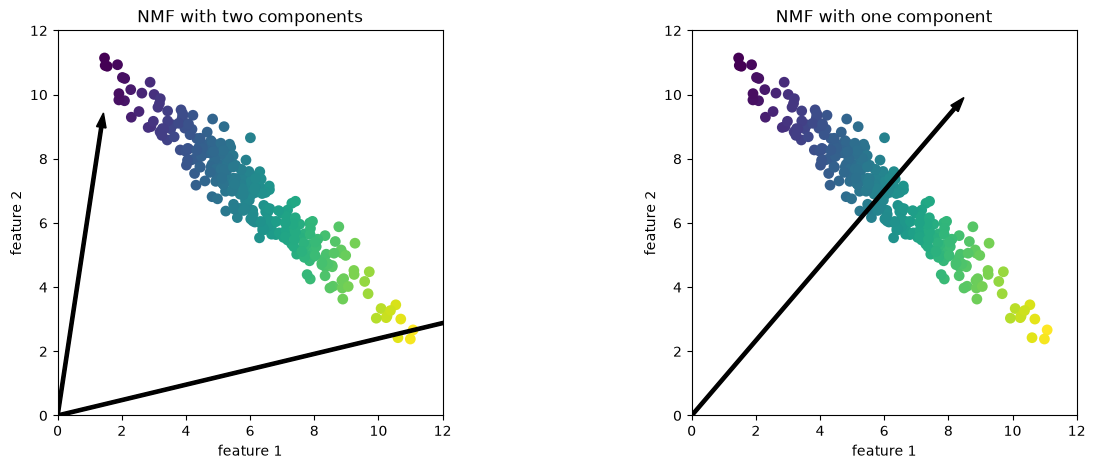

In [ ]:
#NMFの合成データへの適用
#抽出された非負の成分は、原点からのデータ方向

#「PCA＝順位付きの成分」「NMF＝指定個数でチームを作り直す」
#NMFでは成分数を変えると、既存の成分を増減するだけではなく、成分そのものを一から組み直す

mglearn.plots.plot_nmf_illustration()

- NMFの顔画像への適用

c:\Users\seita\anaconda3\envs\ml\Lib\site-packages\sklearn\decomposition\_nmf.py:1723: ConvergenceWarning: Maximum number of iterations 200 reached. Increase it to improve convergence.
  warnings.warn(
c:\Users\seita\anaconda3\envs\ml\Lib\site-packages\sklearn\decomposition\_nmf.py:1723: ConvergenceWarning: Maximum number of iterations 200 reached. Increase it to improve convergence.
  warnings.warn(
c:\Users\seita\anaconda3\envs\ml\Lib\site-packages\sklearn\decomposition\_nmf.py:1723: ConvergenceWarning: Maximum number of iterations 200 reached. Increase it to improve convergence.
  warnings.warn(
c:\Users\seita\anaconda3\envs\ml\Lib\site-packages\sklearn\decomposition\_nmf.py:1723: ConvergenceWarning: Maximum number of iterations 200 reached. Increase it to improve convergence.
  warnings.warn(


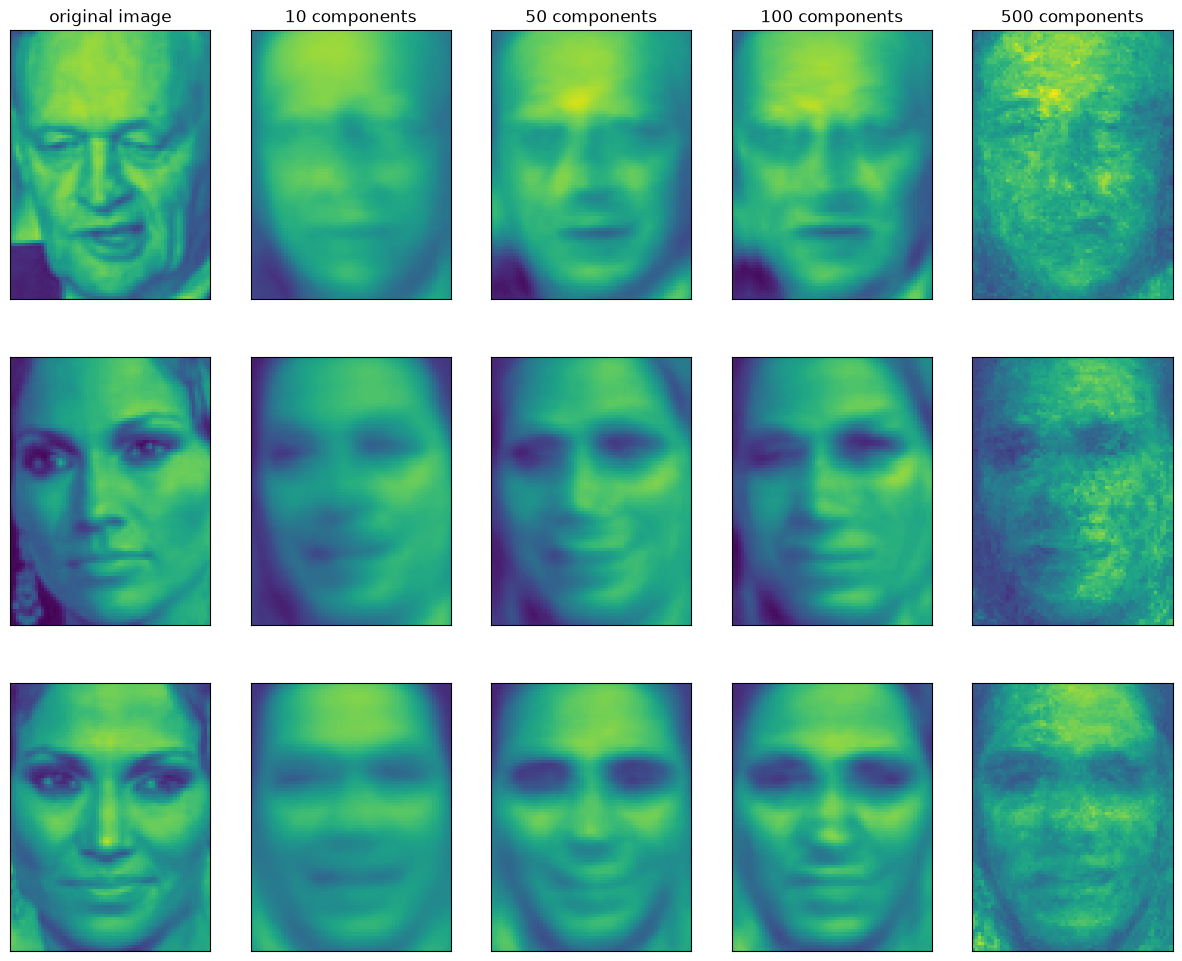

In [ ]:
#PCA → できるだけ上手に圧縮・再構成する方向を重視
#NMF → 非負という制約を守りながら、パーツの組み合わせで再構成する

mglearn.plots.plot_nmf_faces(x_train,x_test,image_shape)

c:\Users\seita\anaconda3\envs\ml\Lib\site-packages\sklearn\decomposition\_nmf.py:1723: ConvergenceWarning: Maximum number of iterations 200 reached. Increase it to improve convergence.
  warnings.warn(


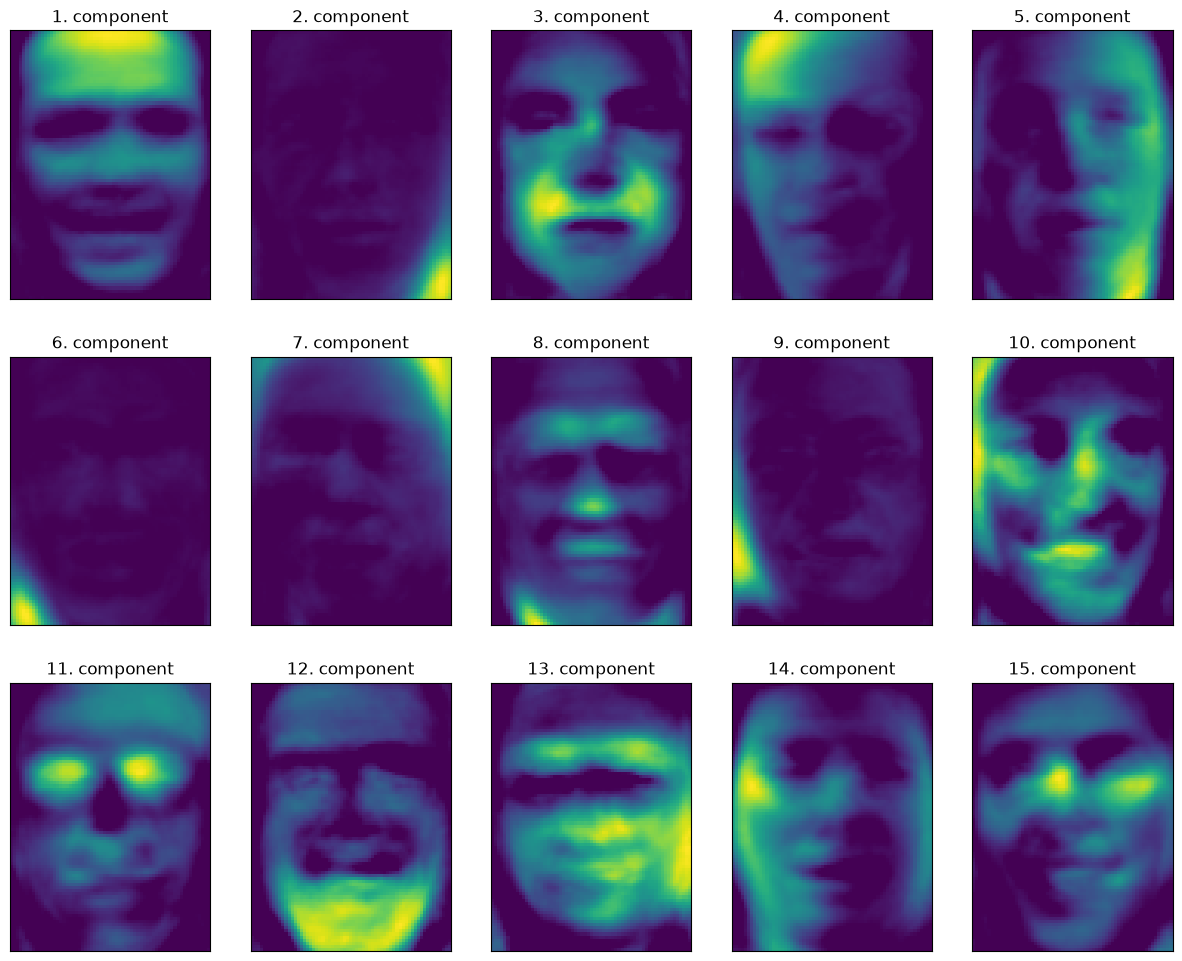

In [ ]:
#データを見る手始めとして、最初の15の成分を見てみる
from sklearn.decomposition import NMF

nmf = NMF(
    n_components=15,
    random_state=0
)

nmf.fit(x_train)

x_train_nmf = nmf.transform(x_train)
x_test_nmf = nmf.transform(x_test)


#PCAで得られた成分よりもはるかに顔のプロトタイプをとらえていることがわかる
fix, axes = plt.subplots(3, 5, figsize=(15, 12), subplot_kw={'xticks': (), 'yticks': ()})
for i, (component, ax) in enumerate(zip(nmf.components_, axes.ravel())):
    ax.imshow(component.reshape(image_shape), cmap="viridis")
    ax.set_title("{}. component".format(i + 1))

Text(0, 0.5, 'Signal')

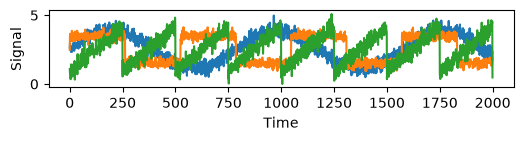

In [50]:
#「成分を追加する」はできる
#「成分をマイナスして打ち消す」はできない
#追加していく構造を持つデータに対して最もうまく機能する

#３つの信号源からの信号が組み合わされた信号を考える
S = mglearn.datasets.make_signals()
plt.figure(figsize=(6, 1))
plt.plot(S,"-")
plt.xlabel("Time")
plt.ylabel("Signal")

In [52]:
#データを混ぜて１００次元の状態を作る
A = np.random.RandomState(0).uniform(size=(100, 3))
X = np.dot(S,A.T)

print("X.shape:{}".format(X.shape))

X.shape:(2000, 100)


In [54]:
#この100個の混合信号、実は3個の信号を混ぜて作ったんだけど、元の3個を見つけられる？
#NMFは、非負の制約を課すことで、元の信号をうまく分離することができる

nmf = NMF(
    n_components=3,
    random_state=42
)

S_ = nmf.fit(X).transform(X)
print("Recovered signals shape:{}".format(S_.shape))

Recovered signals shape:(2000, 3)


In [ ]:
#比較のためにPCAを使ってみる
pca = PCA(
    n_components=3,
    random_state=42
)

H = pca.fit(X).transform(X)

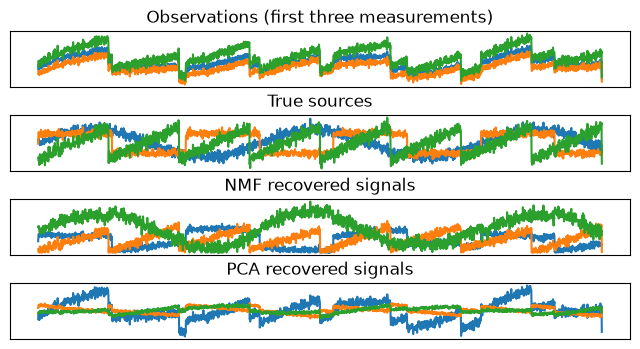

In [56]:
#NMFとPCAの結果を比較するために、元の信号と再構成された信号をプロットしてみる
models = [X,S,S_,H]
names = ["Observations (first three measurements)",
         "True sources",
         "NMF recovered signals",
         "PCA recovered signals"]

fig, axes = plt.subplots(4, figsize=(8, 4),gridspec_kw={"hspace":.5},subplot_kw={"xticks":(),"yticks":()})

for model,name,ax in zip(models,names,axes):
    ax.set_title(name)
    ax.plot(model[:,:3],"-")

- t-SENを用いた多様体学習


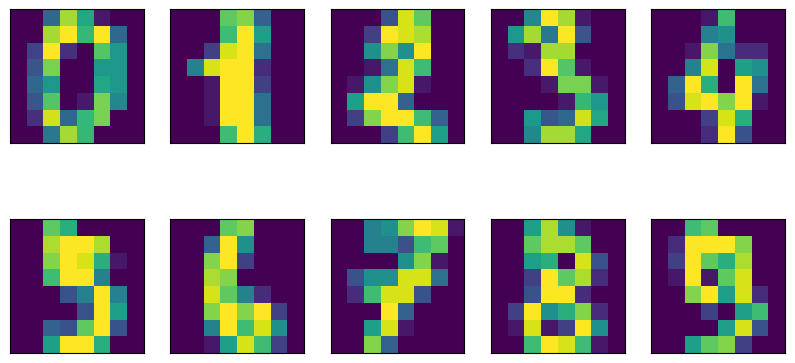

In [58]:
from sklearn.datasets import load_digits
digits = load_digits()

fig,axes = plt.subplots(2,5,figsize=(10,5),subplot_kw={"xticks":(),"yticks":()})
for ax,img in zip(axes.ravel(),digits.images):
    ax.imshow(img)

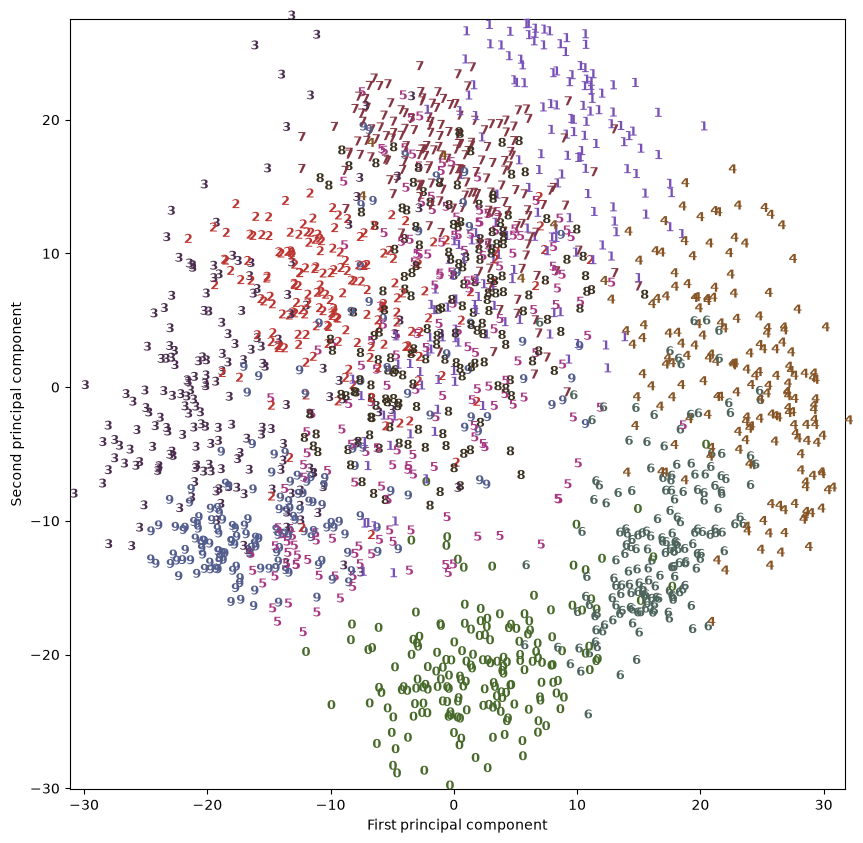

In [59]:
#PCAを使って二次元にして可視化してみる
pca = PCA(n_components=2)
pca.fit(digits.data)
digits_pca = pca.transform(digits.data)
colors = ["#476A2A", "#7851B8", "#BD3430", "#4A2D4E", "#875525",
          "#A83683", "#4E655E", "#853541", "#3A3120", "#535D8E"]
plt.figure(figsize=(10, 10))
plt.xlim(digits_pca[:, 0].min(), digits_pca[:, 0].max())
plt.ylim(digits_pca[:, 1].min(), digits_pca[:, 1].max())
for i in range(len(digits.data)):

    plt.text(digits_pca[i, 0], digits_pca[i, 1], str(digits.target[i]),
             color = colors[digits.target[i]],
             fontdict={'weight': 'bold', 'size': 9})
plt.xlabel("First principal component")
plt.ylabel("Second principal component")

plt.show()


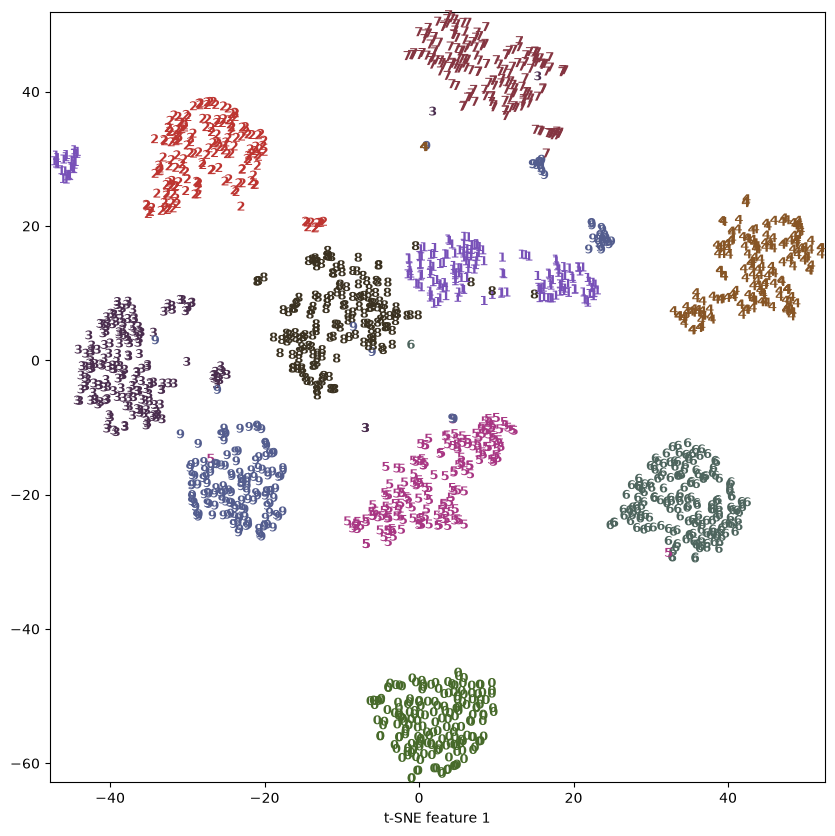

In [61]:
#t-SNEを使って、手書き数字データセットの特徴量を二次元に削減して可視化する
#どの特徴量が分類に重要なのか」ではなく「似たデータ同士がどんな集まりを作っているか」を調べることができる

from sklearn.manifold import TSNE
tsne = TSNE(random_state=42)
#fitではなく、fit_transformを使って、学習と変換を同時に行う(TSENにはfit_transformしかない)
digits_tsne = tsne.fit_transform(digits.data)

plt.figure(figsize=(10, 10))
plt.xlim(digits_tsne[:, 0].min(), digits_tsne[:, 0].max() + 1)
plt.ylim(digits_tsne[:, 1].min(), digits_tsne[:, 1].max() + 1)
for i in range(len(digits.data)):
    plt.text(digits_tsne[i, 0], digits_tsne[i, 1], str(digits.target[i]),
             color = colors[digits.target[i]],
             fontdict={'weight': 'bold', 'size': 9})
plt.xlabel("t-SNE feature 0")
plt.xlabel("t-SNE feature 1")
plt.show()